In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# Paths
# --------------------------------------------------

DATA_DIR = Path(
    "..."
)


# --------------------------------------------------
# Load hand-crafted representations
# --------------------------------------------------

df_rhythm = pd.read_csv(
    DATA_DIR / "df_rhythm_persian.csv"
)

df_egemaps = pd.read_csv(
    DATA_DIR / "persian_egemaps_features.csv"
)


# --------------------------------------------------
# Initial inspection
# --------------------------------------------------

print("Rhythm shape:", df_rhythm.shape)
display(df_rhythm.head())

print("\neGeMAPS shape:", df_egemaps.shape)
display(df_egemaps.head())


Rhythm shape: (210, 36)


,File_Name,Language,Speaker,Year_of_Birth,Age,Gender,ID,Task,percent_V,deltaV,...,varcoM_f0,varcoP_f0,std_int_peak,std_int_mean,nPVI_int_mean,rPVI_int_mean,nPVI_int_peak,rPVI_int_peak,varcoM_int,varcoP_int
0,P_1984_F_22_mf.Table,Persian,P22,1984,40,Female,P_1984_F_22,m(f),34.911467,0.065863,...,3.330818,4.331199,3.252073,3.273839,3.616497,2.477725,3.122346,2.248257,4.740672,4.500871
1,P_1984_F_22_mi.Table,Persian,P22,1984,40,Female,P_1984_F_22,m(i),41.647792,0.091662,...,3.072454,4.020044,3.714772,3.848121,4.185725,2.874938,3.217598,2.311941,5.531084,5.117501
2,P_1984_F_22_rf.Table,Persian,P22,1984,40,Female,P_1984_F_22,r(f),35.853487,0.031060,...,3.647513,4.377586,3.228572,3.494776,4.532859,3.137796,3.498564,2.569650,4.997392,4.392098
3,P_1984_F_22_ri.Table,Persian,P22,1984,40,Female,P_1984_F_22,r(i),38.046579,0.037567,...,3.963287,4.517739,4.368131,4.437188,5.063604,3.541303,4.451029,3.275942,6.235604,5.839005
4,P_1984_F_22_sc.Table,Persian,P22,1984,40,Female,P_1984_F_22,con,35.492986,0.062758,...,4.193059,4.619762,4.307762,4.239625,4.387421,3.031325,3.739540,2.703945,6.075201,5.890475



eGeMAPS shape: (210, 93)


,speaker,task,file,feature_set,feature_level,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,P_1984_F_22,con,/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,30.840261,0.206127,29.507471,32.280730,35.195034,...,-0.028468,-0.004294,0.240401,3.707971,2.138141,0.318725,0.288210,0.141793,0.296321,-23.748556
1,P_1984_F_22,m(f),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,31.837244,0.162490,30.975094,32.620117,34.096195,...,-0.023735,-0.007394,0.188482,3.647944,1.854266,0.343047,0.364948,0.203273,0.605981,-25.320765
2,P_1984_F_22,m(i),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,31.966824,0.162195,30.828010,32.912200,35.221653,...,-0.030313,-0.005346,0.158577,3.117275,1.607805,0.372735,0.326186,0.261275,0.563466,-24.896715
3,P_1984_F_22,pic,/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,30.766730,0.170645,29.782148,31.453970,33.911420,...,-0.021049,-0.009475,0.193041,3.426791,1.958893,0.348409,0.304349,0.162183,0.290133,-25.175325
4,P_1984_F_22,r(f),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,32.765984,0.149452,30.815640,33.042420,35.986153,...,-0.022317,-0.010229,0.257678,4.448354,2.514774,0.261950,0.224554,0.132791,0.281630,-23.980452


In [4]:
# --------------------------------------------------
# Harmonize speaker IDs
# --------------------------------------------------

df_rhythm["speaker_id"] = df_rhythm["Speaker"]

df_egemaps["speaker_id"] = (
    "P" + df_egemaps["speaker"].str.extract(r"_(\d{2})$")[0]
)


# --------------------------------------------------
# Define feature columns
# --------------------------------------------------

rhythm_metadata = [
    "File_Name",
    "Language",
    "Speaker",
    "Year_of_Birth",
    "Age",
    "Gender",
    "ID",
    "Task",
    "speaker_id",
]

egemaps_metadata = [
    "speaker",
    "task",
    "file",
    "feature_set",
    "feature_level",
    "speaker_id",
]

rhythm_features = [
    col for col in df_rhythm.columns
    if col not in rhythm_metadata
]

egemaps_features = [
    col for col in df_egemaps.columns
    if col not in egemaps_metadata
]


# --------------------------------------------------
# Basic checks
# --------------------------------------------------

print("Rhythm")
print("Recordings:", len(df_rhythm))
print("Speakers:", df_rhythm["speaker_id"].nunique())
print("Tasks:", df_rhythm["Task"].nunique())
print("Features:", len(rhythm_features))

print("\neGeMAPS")
print("Recordings:", len(df_egemaps))
print("Speakers:", df_egemaps["speaker_id"].nunique())
print("Tasks:", df_egemaps["task"].nunique())
print("Features:", len(egemaps_features))


# Check correspondence between datasets
rhythm_pairs = set(
    zip(df_rhythm["speaker_id"], df_rhythm["Task"])
)

egemaps_pairs = set(
    zip(df_egemaps["speaker_id"], df_egemaps["task"])
)

assert set(df_rhythm["speaker_id"]) == set(df_egemaps["speaker_id"])
assert rhythm_pairs == egemaps_pairs

print("\nSpeaker sets match.")
print("Speaker × task combinations match.")

Rhythm
Recordings: 210
Speakers: 30
Tasks: 7
Features: 28

eGeMAPS
Recordings: 210
Speakers: 30
Tasks: 7
Features: 88

Speaker sets match.
Speaker × task combinations match.


# Standardization and PCA

In [5]:
# --------------------------------------------------
# Standardization and PCA
# --------------------------------------------------

def fit_pca(df, features):
    X = df[features].to_numpy()

    # Z-standardize each acoustic feature
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA
    pca = PCA()
    scores = pca.fit_transform(X_scaled)

    # PCA diagnostics
    eigenvalues = pca.explained_variance_
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    summary = pd.DataFrame({
        "PC": np.arange(1, len(eigenvalues) + 1),
        "Eigenvalue": eigenvalues,
        "Explained_variance": explained,
        "Cumulative_variance": cumulative
    })

    # Kaiser-Guttman criterion
    n_retained = int(np.sum(eigenvalues > 1))

    return {
        "X_scaled": X_scaled,
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "summary": summary,
        "n_retained": n_retained,
    }

In [6]:
rhythm_pca = fit_pca(
    df_rhythm,
    rhythm_features
)

egemaps_pca = fit_pca(
    df_egemaps,
    egemaps_features
)

In [7]:
print("\nRhythm:")
print(
    rhythm_pca["summary"]
    .head(15)
    .round(4)
)

print("\neGeMAPS:")
print(
    egemaps_pca["summary"]
    .head(25)
    .round(4)
)


Rhythm:
    PC  Eigenvalue  Explained_variance  Cumulative_variance
0    1      8.6436              0.3072               0.3072
1    2      6.7129              0.2386               0.5458
2    3      4.6792              0.1663               0.7122
3    4      2.6503              0.0942               0.8064
4    5      1.1929              0.0424               0.8488
5    6      1.0185              0.0362               0.8850
6    7      0.7973              0.0283               0.9133
7    8      0.7431              0.0264               0.9397
8    9      0.6037              0.0215               0.9612
9   10      0.4321              0.0154               0.9765
10  11      0.2122              0.0075               0.9841
11  12      0.1809              0.0064               0.9905
12  13      0.1046              0.0037               0.9942
13  14      0.0674              0.0024               0.9966
14  15      0.0282              0.0010               0.9976

eGeMAPS:
    PC  Eigenvalue  E

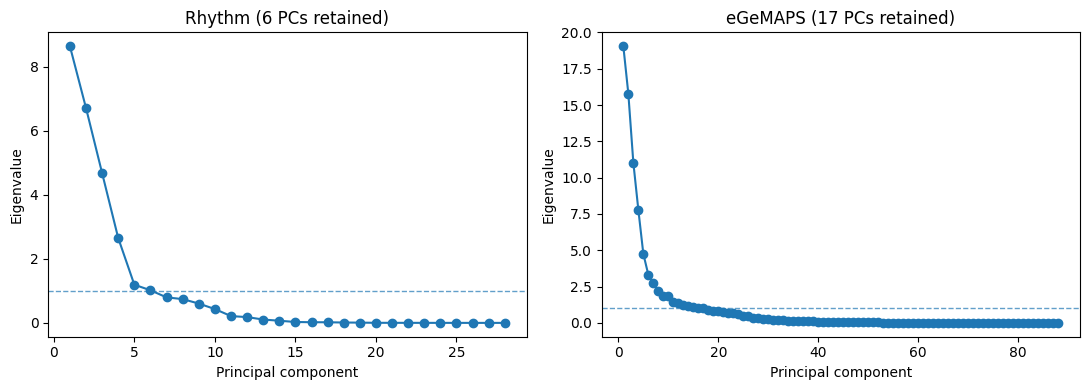

In [8]:
# --------------------------------------------------
# Scree plots for PCA retention
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

# Rhythm
axes[0].plot(
    rhythm_pca["summary"]["PC"],
    rhythm_pca["summary"]["Eigenvalue"],
    marker="o"
)

axes[0].axhline(
    1,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title(
    f"Rhythm ({rhythm_pca['n_retained']} PCs retained)"
)


# eGeMAPS
axes[1].plot(
    egemaps_pca["summary"]["PC"],
    egemaps_pca["summary"]["Eigenvalue"],
    marker="o"
)

axes[1].axhline(
    1,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title(
    f"eGeMAPS ({egemaps_pca['n_retained']} PCs retained)"
)

plt.tight_layout()
plt.show()

In [9]:
def plot_speaker_pca(
    df,
    pca_result,
    speaker_col,
    task_col,
    highlight_speakers,
    title,
    save_path=None
):
    scores = pca_result["scores"]

    plot_df = pd.DataFrame({
        "PC1": scores[:, 0],
        "PC2": scores[:, 1],
        "speaker": df[speaker_col].values,
        "task": df[task_col].values
    })

    fig, ax = plt.subplots(figsize=(10, 7))

    # --------------------------------------------------
    # Background population
    # --------------------------------------------------

    other = plot_df[
        ~plot_df["speaker"].isin(highlight_speakers)
    ]

    ax.scatter(
        other["PC1"],
        other["PC2"],
        s=30,
        alpha=0.30,
        label="Other speakers"
    )

    # --------------------------------------------------
    # Highlight selected speakers
    # --------------------------------------------------

    for speaker in highlight_speakers:

        sp = plot_df[
            plot_df["speaker"] == speaker
        ]

        ax.scatter(
            sp["PC1"],
            sp["PC2"],
            s=65,
            alpha=0.95,
            label=speaker,
            zorder=3
        )

        # Label each highlighted recording by task
        for _, row in sp.iterrows():

            ax.annotate(
                row["task"],
                (row["PC1"], row["PC2"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8
            )

    # --------------------------------------------------
    # Axis labels
    # --------------------------------------------------

    pc1 = (
        pca_result["pca"]
        .explained_variance_ratio_[0]
        * 100
    )

    pc2 = (
        pca_result["pca"]
        .explained_variance_ratio_[1]
        * 100
    )

    ax.set_xlabel(
        f"PC1 ({pc1:.1f}% variance)"
    )

    ax.set_ylabel(
        f"PC2 ({pc2:.1f}% variance)"
    )

    ax.set_title(title)

    ax.axhline(
        0,
        linewidth=0.5,
        alpha=0.3
    )

    ax.axvline(
        0,
        linewidth=0.5,
        alpha=0.3
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

    return plot_df

In [ ]:
OUTPUT_DIR = Path(
    "..."
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

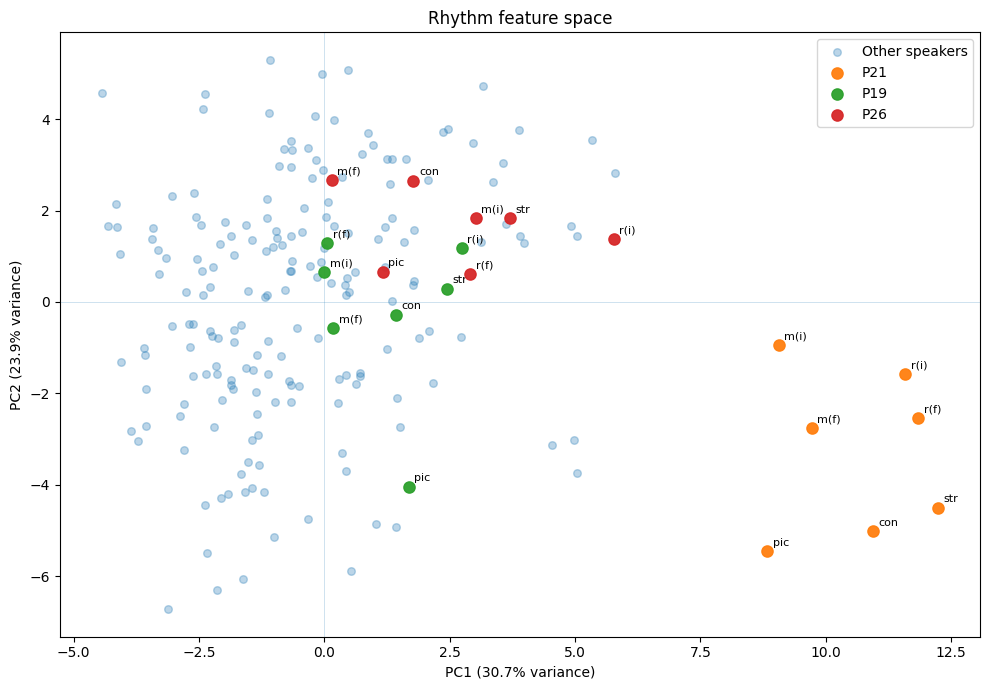

In [11]:
rhythm_plot = plot_speaker_pca(
    df=df_rhythm,
    pca_result=rhythm_pca,
    speaker_col="speaker_id",
    task_col="Task",
    highlight_speakers=["P21", "P19", "P26"],
    title="Rhythm feature space",
    save_path=OUTPUT_DIR / "PCA_rhythm.pdf"
)

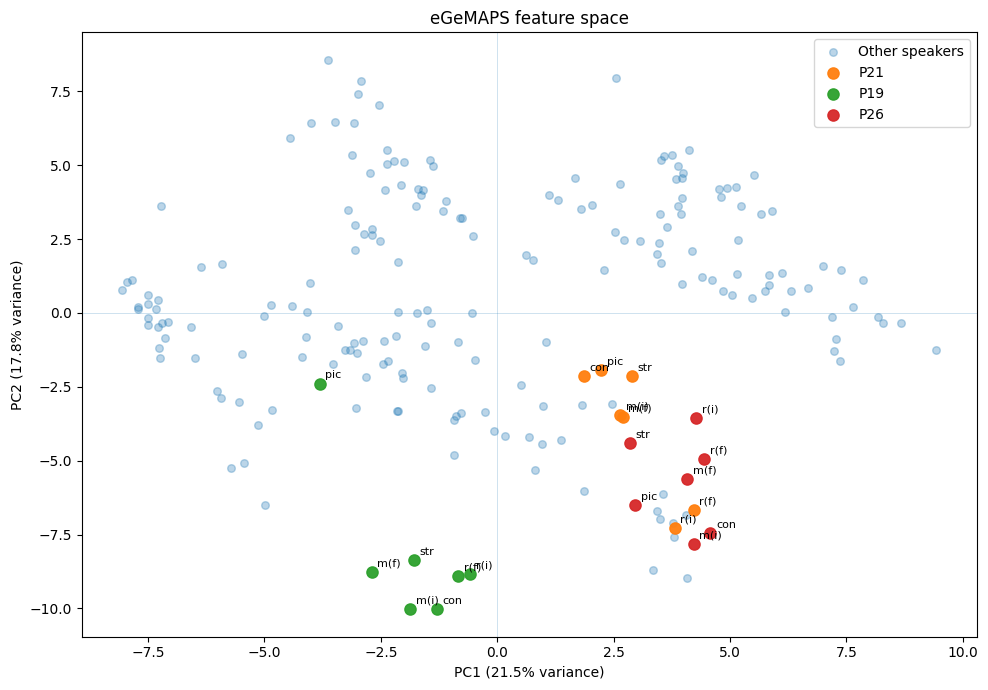

In [12]:
egemaps_plot = plot_speaker_pca(
    df=df_egemaps,
    pca_result=egemaps_pca,
    speaker_col="speaker_id",
    task_col="task",
    highlight_speakers=["P21", "P19", "P26"],
    title="eGeMAPS feature space",
    save_path=OUTPUT_DIR / "PCA_eGeMAPS.pdf"
)

# --------------------------------------------------
# Task-conditioned Mahalanobis peripherality
# --------------------------------------------------

In [13]:

# Task-conditioned Mahalanobis peripherality


def task_conditioned_mahalanobis(
    df,
    pca_result,
    speaker_col,
    task_col
):
    # Retained PCA scores
    k = pca_result["n_retained"]
    scores = pca_result["scores"][:, :k]

    score_cols = [
        f"PC{i+1}" for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # Center retained PC scores within task
    task_means = (
        score_df
        .groupby("task")[score_cols]
        .transform("mean")
    )

    centered = (
        score_df[score_cols]
        - task_means
    )

    centered_values = centered.to_numpy()

    # Pooled covariance matrix
    covariance = np.cov(
        centered_values,
        rowvar=False
    )

    # Check numerical stability
    condition_number = np.linalg.cond(
        covariance
    )

    covariance_inv = np.linalg.inv(
        covariance
    )

    # Mahalanobis distance from task centre
    md_squared = np.einsum(
        "ij,jk,ik->i",
        centered_values,
        covariance_inv,
        centered_values
    )

    score_df["mahalanobis"] = np.sqrt(
        md_squared
    )

    return (
        score_df,
        covariance,
        condition_number
    )

In [14]:
rhythm_md, rhythm_cov, rhythm_condition = (
    task_conditioned_mahalanobis(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)

egemaps_md, egemaps_cov, egemaps_condition = (
    task_conditioned_mahalanobis(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)

In [15]:
print(
    "Rhythm covariance condition number:",
    rhythm_condition
)

print(
    "eGeMAPS covariance condition number:",
    egemaps_condition
)

Rhythm covariance condition number: 9.504955977722188
eGeMAPS covariance condition number: 21.080687715692214


In [16]:
# --------------------------------------------------
# Speaker-level peripherality summaries
# --------------------------------------------------

def summarize_speaker_peripherality(md_df):

    summary = (
        md_df
        .groupby("speaker_id")["mahalanobis"]
        .agg(
            mean_md="mean",
            median_md="median",
            sd_md="std",
            min_md="min",
            max_md="max"
        )
        .reset_index()
        .sort_values(
            "mean_md",
            ascending=False
        )
        .reset_index(drop=True)
    )

    summary["rank"] = np.arange(
        1,
        len(summary) + 1
    )

    return summary


rhythm_speaker_md = (
    summarize_speaker_peripherality(
        rhythm_md
    )
)

egemaps_speaker_md = (
    summarize_speaker_peripherality(
        egemaps_md
    )
)

In [17]:
print("\nRhythm")
print(
    rhythm_speaker_md
    .head(10)
    .round(3)
)

print("\neGeMAPS")
print(
    egemaps_speaker_md
    .head(10)
    .round(3)
)


Rhythm
  speaker_id  mean_md  median_md  sd_md  min_md  max_md  rank
0        P21    4.502      4.644  0.355   3.968   4.943     1
1        P26    3.067      3.088  0.391   2.388   3.572     2
2        P25    3.012      3.130  0.397   2.184   3.351     3
3        P29    2.920      2.931  0.517   2.259   3.542     4
4        P08    2.816      2.892  0.702   1.818   3.768     5
5        P23    2.792      2.685  0.531   2.215   3.836     6
6        P18    2.778      2.624  0.506   2.025   3.459     7
7        P04    2.639      2.486  0.619   1.999   3.655     8
8        P02    2.449      2.494  0.570   1.557   3.112     9
9        P10    2.430      1.773  1.445   1.649   5.616    10

eGeMAPS
  speaker_id  mean_md  median_md  sd_md  min_md  max_md  rank
0        P20    5.833      5.538  1.363   4.263   8.574     1
1        P19    5.444      4.632  2.048   4.500  10.073     2
2        P26    5.378      4.319  2.126   3.974   9.108     3
3        P21    4.955      4.997  0.294   4.492   5.2

In [18]:
from scipy.stats import spearmanr

# --------------------------------------------------
# Compare speaker peripherality across representations
# --------------------------------------------------

speaker_comparison = (
    rhythm_speaker_md[
        ["speaker_id", "mean_md", "sd_md", "rank"]
    ]
    .rename(columns={
        "mean_md": "rhythm_mean_md",
        "sd_md": "rhythm_sd_md",
        "rank": "rhythm_rank"
    })
    .merge(
        egemaps_speaker_md[
            ["speaker_id", "mean_md", "sd_md", "rank"]
        ].rename(columns={
            "mean_md": "egemaps_mean_md",
            "sd_md": "egemaps_sd_md",
            "rank": "egemaps_rank"
        }),
        on="speaker_id"
    )
)

rho, p_value = spearmanr(
    speaker_comparison["rhythm_mean_md"],
    speaker_comparison["egemaps_mean_md"]
)

print(f"Spearman rho = {rho:.3f}")
print(f"p = {p_value:.4f}")

Spearman rho = 0.134
p = 0.4797


In [19]:
speaker_comparison["rank_difference"] = (
    speaker_comparison["rhythm_rank"]
    - speaker_comparison["egemaps_rank"]
)

speaker_comparison["abs_rank_difference"] = (
    speaker_comparison["rank_difference"].abs()
)

speaker_comparison = (
    speaker_comparison
    .sort_values(
        "abs_rank_difference",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    speaker_comparison
    .head(10)
    .round(3)
)

  speaker_id  rhythm_mean_md  rhythm_sd_md  rhythm_rank  egemaps_mean_md  \
0        P23           2.792         0.531            6            3.350   
1        P04           2.639         0.619            8            3.191   
2        P19           1.997         0.266           21            5.444   
3        P10           2.430         1.445           10            3.056   
4        P30           1.861         0.215           24            4.516   
5        P15           1.808         0.524           25            4.236   
6        P29           2.920         0.517            4            3.583   
7        P11           2.396         0.653           11            3.273   
8        P24           1.913         0.223           22            4.167   
9        P16           1.735         0.510           26            3.680   

   egemaps_sd_md  egemaps_rank  rank_difference  abs_rank_difference  
0          0.545            26              -20                   20  
1          0.680     

In [20]:
# --------------------------------------------------
# Permutation test for Spearman correlation
# --------------------------------------------------

rng = np.random.default_rng(42)

n_permutations = 10_000

observed_rho = rho

permuted_rhos = np.empty(n_permutations)

rhythm_values = (
    speaker_comparison["rhythm_mean_md"]
    .to_numpy()
)

egemaps_values = (
    speaker_comparison["egemaps_mean_md"]
    .to_numpy()
)

for i in range(n_permutations):

    permuted_rhos[i] = spearmanr(
        rhythm_values,
        rng.permutation(egemaps_values)
    ).statistic

permutation_p = (
    np.sum(
        np.abs(permuted_rhos)
        >= np.abs(observed_rho)
    ) + 1
) / (n_permutations + 1)

print(
    f"Observed Spearman rho = {observed_rho:.3f}"
)

print(
    f"Permutation p = {permutation_p:.4f}"
)

Observed Spearman rho = 0.134
Permutation p = 0.4798


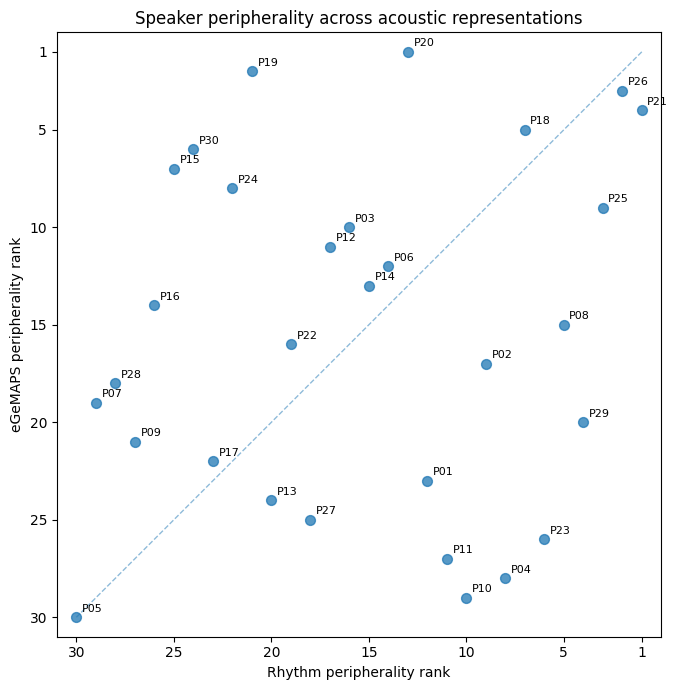

In [22]:
# --------------------------------------------------
# Speaker-rank comparison
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    speaker_comparison["rhythm_rank"],
    speaker_comparison["egemaps_rank"],
    s=50,
    alpha=0.75
)

# Reference line: identical rank in both representations
ax.plot(
    [1, 30],
    [1, 30],
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

# Speaker labels
for _, row in speaker_comparison.iterrows():
    ax.annotate(
        row["speaker_id"],
        (
            row["rhythm_rank"],
            row["egemaps_rank"]
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Rhythm peripherality rank")
ax.set_ylabel("eGeMAPS peripherality rank")

ax.set_xticks(
    [1, 5, 10, 15, 20, 25, 30]
)

ax.set_yticks(
    [1, 5, 10, 15, 20, 25, 30]
)

ax.set_xlim(0, 31)
ax.set_ylim(0, 31)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_title(
    "Speaker peripherality across acoustic representations"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "speaker_rank_comparison.pdf",
    bbox_inches="tight"
)
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()

In [23]:
# --------------------------------------------------
# Cross-representation correspondence by task
# --------------------------------------------------

task_comparison = (
    rhythm_md[
        ["speaker_id", "task", "mahalanobis"]
    ]
    .rename(
        columns={
            "mahalanobis": "rhythm_md"
        }
    )
    .merge(
        egemaps_md[
            ["speaker_id", "task", "mahalanobis"]
        ].rename(
            columns={
                "mahalanobis": "egemaps_md"
            }
        ),
        on=["speaker_id", "task"]
    )
)

task_results = []

for task, group in task_comparison.groupby("task"):

    rho_task, p_task = spearmanr(
        group["rhythm_md"],
        group["egemaps_md"]
    )

    task_results.append({
        "task": task,
        "rho": rho_task,
        "p": p_task
    })

task_results = pd.DataFrame(
    task_results
).sort_values("rho", ascending=False)

print(
    task_results.round(3)
)

   task    rho      p
4  r(f)  0.369  0.045
3   pic  0.253  0.178
6   str  0.190  0.315
1  m(f)  0.156  0.412
0   con  0.131  0.489
2  m(i)  0.021  0.912
5  r(i) -0.037  0.847


In [25]:
# --------------------------------------------------
# RQ1 summary
# --------------------------------------------------

rq1_summary["p_type"] = [
    "permutation",
    "asymptotic",
    "asymptotic",
    "asymptotic",
    "asymptotic",
    "asymptotic",
    "asymptotic",
    "asymptotic"
]

print(rq1_summary.round(3))

rq1_summary.to_csv(
    OUTPUT_DIR / "rq1_correlations.csv",
    index=False
)

                           analysis    rho      p       p_type
0  Speaker-level mean peripherality  0.134  0.480  permutation
1                              r(f)  0.369  0.045   asymptotic
2                               pic  0.253  0.178   asymptotic
3                               str  0.190  0.315   asymptotic
4                              m(f)  0.156  0.412   asymptotic
5                               con  0.131  0.489   asymptotic
6                              m(i)  0.021  0.912   asymptotic
7                              r(i) -0.037  0.847   asymptotic


In [26]:
rq1_summary.to_csv(
    OUTPUT_DIR / "rq1_correlations.csv",
    index=False
)

speaker_comparison.to_csv(
    OUTPUT_DIR / "rq1_speaker_peripherality.csv",
    index=False
)